In [182]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [183]:
import sklearn

In [184]:
df=pd.read_csv("/content/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [185]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [186]:
y.head()

,Outcome
0,1
1,0
2,1
3,0
4,1


<Axes: >

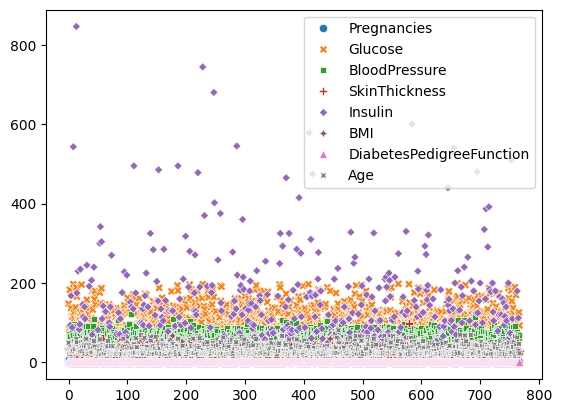

In [187]:
sns.scatterplot(X)

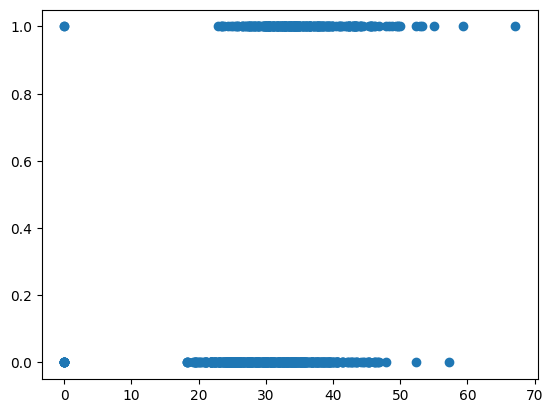

In [188]:
plt.scatter(df["BMI"], df["Outcome"])

(array([[768.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [ 72., 625.,  71.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [656., 112.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [767.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [487., 155.,  70.,  30.,   8.,   9.,   5.,   1.,   2.,   1.],
        [768.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [768.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [768.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.],
        [768.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.]]),
 array([  0. ,  84.6, 169.2, 253.8, 338.4, 423. , 507.6, 592.2, 676.8,
        761.4, 846. ]),
 <a list of 9 BarContainer objects>)

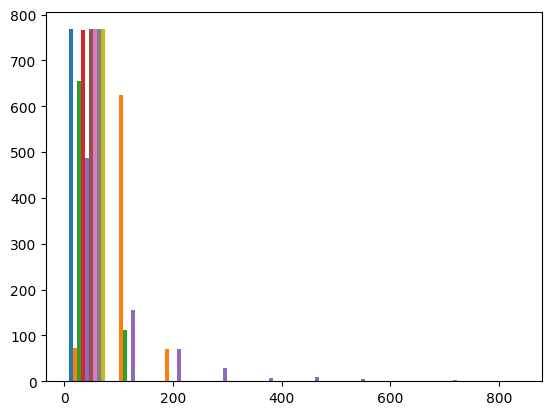

In [189]:
plt.hist(df)

<Axes: xlabel='Pregnancies', ylabel='Count'>

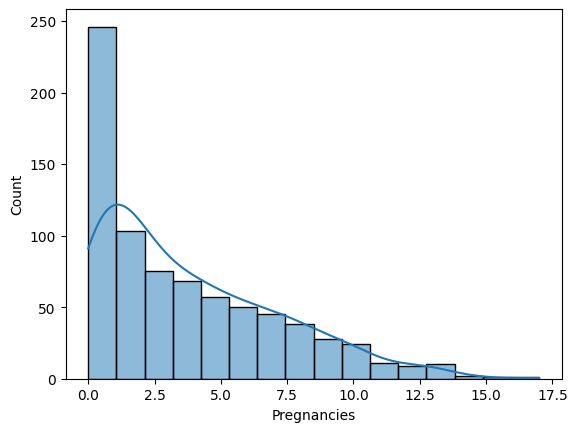

In [190]:
sns.histplot(df["Pregnancies"],kde=True)

<Axes: xlabel='Age', ylabel='Count'>

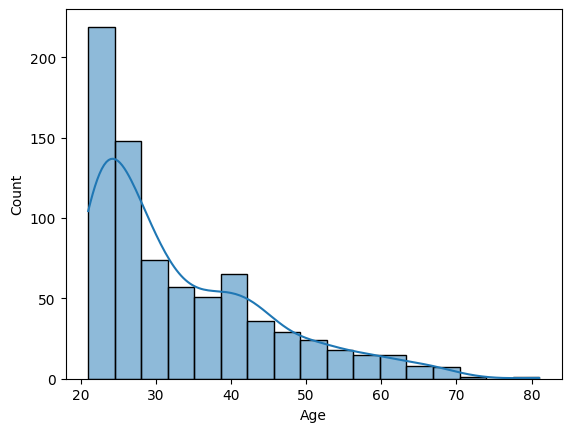

In [191]:
sns.histplot(df["Age"],kde=True)

In [192]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


<Axes: >

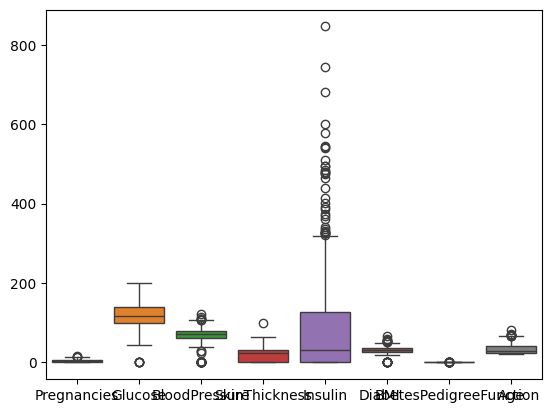

In [193]:
sns.boxplot(X)

In [194]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,stratify=y, random_state=7)

In [195]:
from sklearn.preprocessing import StandardScaler

scaler= StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [196]:
from sklearn.svm import SVR

model=SVR()

model.fit(X_train,y_train)

y_pred=model.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print(f"MAE: {mean_absolute_error(y_test,y_pred)}")
print(f"MSE: {mean_squared_error(y_test,y_pred)}")
print(f"Score: {r2_score(y_test,y_pred)}")

MAE: 0.2879839555902635
MSE: 0.16961725285980353
Score: 0.255066153921648


In [201]:
from sklearn.svm import SVC

model=SVC(kernel="linear")

model.fit(X_train,y_train)

y_pred=model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print(f"Accuarcay: {accuracy_score(y_test,y_pred)}")
print(f"Report: {classification_report(y_test,y_pred)}")

Accuarcay: 0.7792207792207793
Report:               precision    recall  f1-score   support

           0       0.80      0.88      0.84       100
           1       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



In [205]:
## Hyperparameter tuning
params={
        "C": [0.1, 1, 10],
        "kernel": ["linear", "poly", "rbf", "sigmoid"],
        "gamma": ["scale", "auto"]
    }

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

gs= GridSearchCV(estimator=model,param_grid=params,cv=5,scoring="accuracy",refit=True,verbose=2)
gs.fit(X_train,y_train)

print(f"Best Params: {gs.best_params_}")
print(f"Best Score: {gs.best_score_}")
model2=SVC()
model2.set_params(**gs.best_params_)
model2.fit(X_train,y_train)
y_pred=model2.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report
print(f"Accuarcay: {accuracy_score(y_test,y_pred)}")
print(f"Report: {classification_report(y_test,y_pred)}")

print("*"*50)
rnd= RandomizedSearchCV(estimator=model,param_distributions=params,cv=5,scoring="accuracy",refit=True,verbose=2)
rnd.fit(X_train,y_train)

print(f"Best Params: {gs.best_params_}")
print(f"Best Score: {gs.best_score_}")
model3=SVC()
model3.set_params(**gs.best_params_)
model3.fit(X_train,y_train)
y_pred_2=model3.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report
print(f"Accuarcay: {accuracy_score(y_test,y_pred_2)}")
print(f"Report: {classification_report(y_test,y_pred_2)}")
print("*"*50)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ..................C=0.1, gamma=scale, kernel=linear; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END ....................C=0.1, gamma=scale, kernel=poly; total time=   0.0s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=   0.0s
[CV] END .....................C=0.1, gamma=scal

In [200]:
## Prediction
input_data= (10,139,80,106,0,27.1,1.441,77)
data=np.asarray(input_data).reshape(1,-1)
data= scaler.transform(data)
y_pred1=model.predict(data)

if y_pred1[0]==0:
  print("Not Diabetic...")
else:
  if y_pred1[0]==1:
    print("Diabetic")

Diabetic


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [206]:
## Prediction
input_data= (10,139,80,106,0,27.1,1.441,77)
data=np.asarray(input_data).reshape(1,-1)
data= scaler.transform(data)
y_pred1=model2.predict(data)

if y_pred1[0]==0:
  print("Not Diabetic...")
else:
  if y_pred1[0]==1:
    print("Diabetic")


Diabetic


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [207]:
## Prediction
input_data= (10,139,80,106,0,27.1,1.441,77)
data=np.asarray(input_data).reshape(1,-1)
data= scaler.transform(data)
y_pred1=model3.predict(data)

if y_pred1[0]==0:
  print("Not Diabetic...")
else:
  if y_pred1[0]==1:
    print("Diabetic")

Diabetic


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
